# 📊 한국 데이터분석 채용시장 분석
## 인디스워크(IN THIS WORK) 채용공고 전수 크롤링 & 분석

**분석 목적**: 2026년 3월 기준 데이터분석 직군 채용시장의 트렌드를 파악하고,
취업 준비에 필요한 스킬셋과 시장 구조를 시각화합니다.

---
- **데이터 출처**: https://inthiswork.com/data
- **수집 기간**: 2026년 3월
- **수집 공고 수**: 317건 (전수 수집)
- **수집 방법**: Claude in Chrome 확장을 활용한 JavaScript 기반 동적 크롤링

## 0. 라이브러리 임포트 및 환경 설정

In [1]:
import os, site, shutil

# ── 1. matplotlib 폰트 캐시 삭제 ──────────────────────────
import matplotlib
cache_dir = matplotlib.get_cachedir()
for fname in os.listdir(cache_dir):
    try: os.remove(os.path.join(cache_dir, fname))
    except: pass

# ── 2. 라이브러리 import ──────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ── 3. NanumGothic TTF 찾아 등록 ─────────────────────────
FONT_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "NanumGothic.ttf")

def find_nanum():
    for sp in site.getsitepackages() + [site.getusersitepackages()]:
        p = os.path.join(sp, "koreanize_matplotlib", "fonts", "NanumGothic.ttf")
        if os.path.exists(p):
            return p
    for p in ["/Library/Fonts/NanumGothic.ttf",
               os.path.expanduser("~/Library/Fonts/NanumGothic.ttf")]:
        if os.path.exists(p):
            return p
    return None

src = find_nanum()
if src and not os.path.exists(FONT_PATH):
    shutil.copy(src, FONT_PATH)

if not os.path.exists(FONT_PATH):
    import urllib.request
    url = "https://github.com/ychoi-kr/koreanize-matplotlib/raw/main/koreanize_matplotlib/fonts/NanumGothic.ttf"
    urllib.request.urlretrieve(url, FONT_PATH)

fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont(FONT_PATH)

# ── 4. sns.set_theme() 먼저, 폰트 설정은 반드시 그 후에 ──
sns.set_theme(style="darkgrid", palette="husl")

# ✅ sns.set_theme()이 font.family를 덮어쓰므로 반드시 이후에 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

# ── 5. 확인 ──────────────────────────────────────────────
print(f"✅ font.family: {plt.rcParams['font.family']}")

# 테스트 차트
fig, ax = plt.subplots(figsize=(4, 1.5))
ax.set_title("한글 테스트: 데이터분석 채용시장")
ax.text(0.5, 0.5, "Python · SQL · 머신러닝", ha="center", va="center",
        transform=ax.transAxes, fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()
plt.close()

✅ NanumGothic 등록 완료: /Users/namgungsin/job-market-analytics-pipeline/.venv/lib/python3.14/site-packages/koreanize_matplotlib/fonts/NanumGothic.ttf
등록된 Nanum 폰트: {'Nanum Gothic', 'NanumGothic', 'Nanum Myeongjo', 'Nanum Brush Script'}


## 1. 데이터 수집 방법론

### 크롤링 파이프라인

```
[인디스워크 /data 페이지] → [13페이지 순회 (paged1=N)] → [317개 공고 URL 수집]
        ↓
[각 공고 상세 페이지 병렬 fetch (8개 동시)] → [정규식 기반 필드 추출]
        ↓
[데이터 정제 & 분류] → [CSV 저장 & 분석]
```

### 추출 필드
| 필드 | 추출 방법 | 완성도 |
|------|-----------|--------|
| 회사명 | 제목 파싱 (｜ 구분) | 100% |
| 직무명 | 제목 파싱 | 100% |
| 고용형태 | 정규식 `근무형태:` | ~60% |
| 근무지역 | 정규식 `근무지역:` | ~79% |
| 급여 | 정규식 `급여:` | ~18% |
| 요구스킬 | 키워드 사전 매칭 (37개) | ~73% |

## 2. 데이터 로드 및 기본 탐색

In [2]:
# CSV 파일 로드 (동일 디렉토리에 inthiswork_data_jobs.csv 필요)
df = pd.read_csv('inthiswork_data_jobs.csv')

print(f'총 공고 수: {len(df)}건')
print(f'컬럼: {list(df.columns)}')
df.head()

총 공고 수: 85건
컬럼: ['회사명', '직무/포지션', '고용형태', '근무지역(상세)', '근무지역(도시)', '근무기간', '급여', '요구스킬', '스킬수', '기업규모', '직무카테고리', '공고URL']


,회사명,직무/포지션,고용형태,근무지역(상세),근무지역(도시),근무기간,급여,요구스킬,스킬수,기업규모,직무카테고리,공고URL
0,콘크리트파머스,[유통사업부] MD 채용 (경력 무관),NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,https://inthiswork.com/archives/313459
1,KMAC,26년 3월 AA(채용전환형 인턴) 모집,인턴,NaN,기타,NaN,NaN,NaN,0,중견기업,기타,https://inthiswork.com/archives/313001
2,알파코드,AI 서비스 개발자 (AI Service Developer),NaN,NaN,기타,NaN,NaN,"데이터 파이프라인, TensorFlow, PyTorch, AWS, GCP, Azure",6,스타트업,기타,https://inthiswork.com/archives/313346
3,에프앤엘코퍼레이션,[인턴] CEO Staff – Research Analyst,인턴,"F&L 본사(서울특별시 영등포구 150, 생각공장 당산 C동 14층)",서울,NaN,"3,000만원(식대, 고정OT 포함)",Excel,1,스타트업,데이터분석가,https://inthiswork.com/archives/313306
4,애커튼파트너스,AX 컨설턴트 (인턴),인턴,NaN,기타,6개월 (평가에 따라 정규직 전환 여부 검토),NaN,"데이터 분석, 머신러닝, 딥러닝, Python, SQL, Excel",6,스타트업,리서치/컨설팅,https://inthiswork.com/archives/313225


In [3]:
# 기본 통계
print('=== 결측치 현황 ===')
print(df.isnull().sum())
print(f"\n평균 요구 스킬 수: {df['스킬수'].mean():.1f}개")
print(f"급여 정보 있는 공고: {df['급여'].notna().sum()}건 ({df['급여'].notna().mean()*100:.1f}%)")

=== 결측치 현황 ===
회사명          0
직무/포지션       0
고용형태        38
근무지역(상세)    83
근무지역(도시)     9
근무기간        80
급여          79
요구스킬        48
스킬수          0
기업규모         9
직무카테고리       9
공고URL        0
dtype: int64

평균 요구 스킬 수: 1.3개
급여 정보 있는 공고: 6건 (7.1%)


## 3. 직무 카테고리 & 고용형태 분석

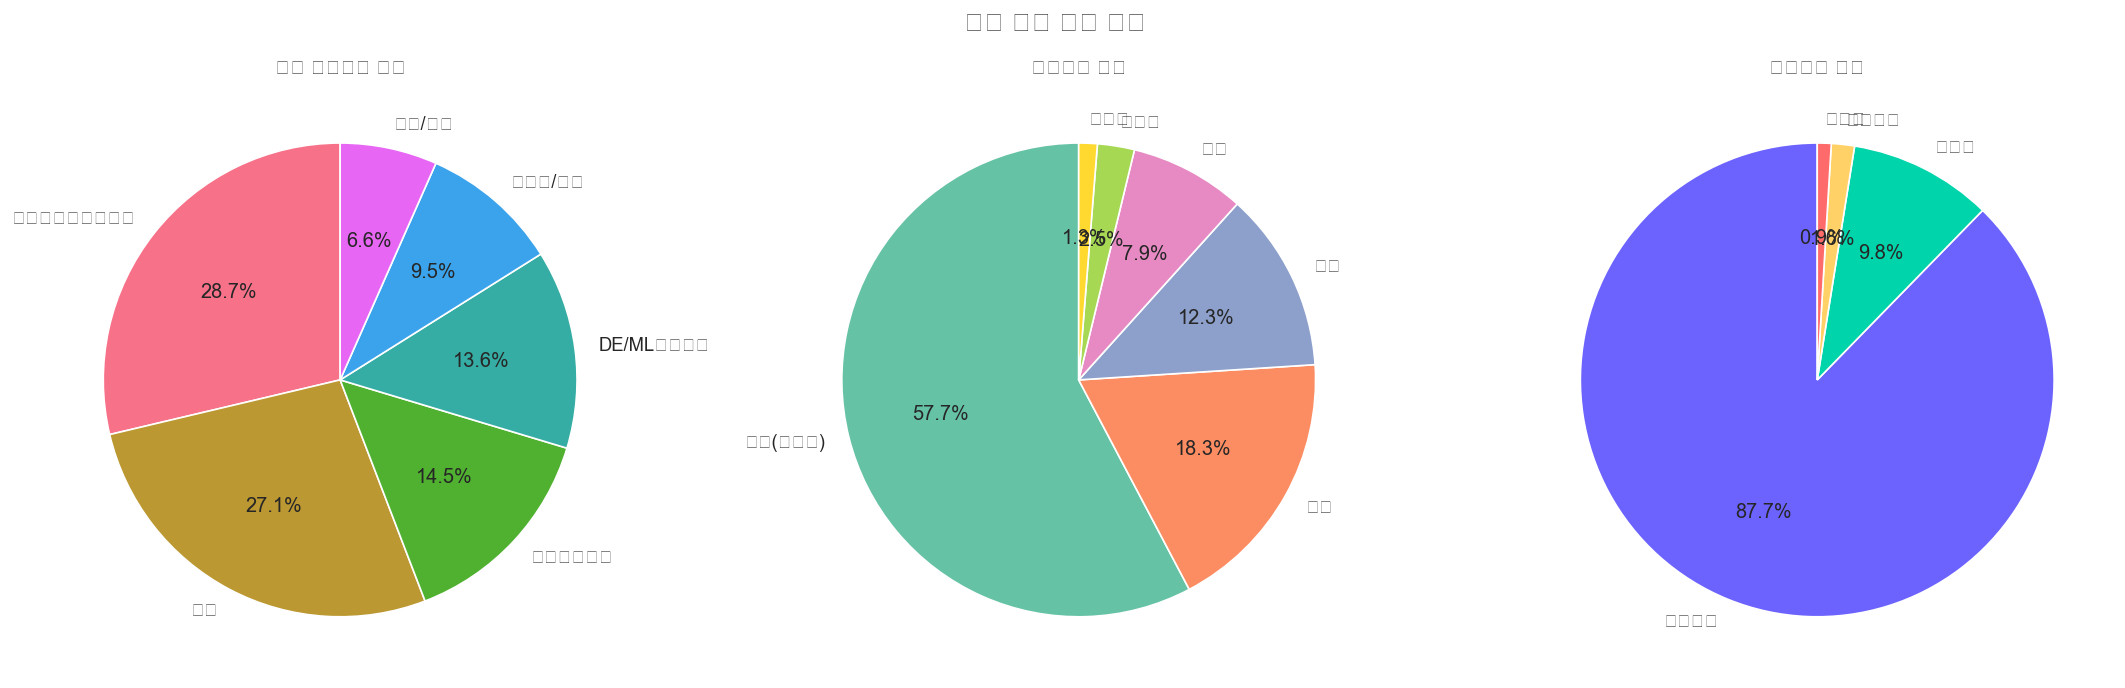

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('채용 시장 구조 분석', fontsize=16, fontweight='bold')

# 직무 카테고리
cat_data = pd.Series({'데이터사이언티스트':91, '기타':86, '데이터분석가':46,
                       'DE/ML엔지니어':43, '리서치/인턴':30, '기획/전략':21})
axes[0].pie(cat_data, labels=cat_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('husl', len(cat_data)), startangle=90)
axes[0].set_title('직무 카테고리 분포')

# 고용형태
emp_data = pd.Series({'기타(미표기)':183, '신입':58, '인턴':39, '경력':25, '계약직':8, '정규직':4})
axes[1].pie(emp_data, labels=emp_data.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set2', len(emp_data)), startangle=90)
axes[1].set_title('고용형태 분포')

# 기업규모
size_data = pd.Series({'스타트업':278, '대기업':31, '중견기업':5, '외국계':3})
axes[2].pie(size_data, labels=size_data.index, autopct='%1.1f%%',
            colors=['#6c63ff','#00d4aa','#ffd166','#ff6b6b'], startangle=90)
axes[2].set_title('기업규모 분포')

plt.tight_layout()
plt.savefig('chart_structure.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. 요구 스킬 분석 (핵심)

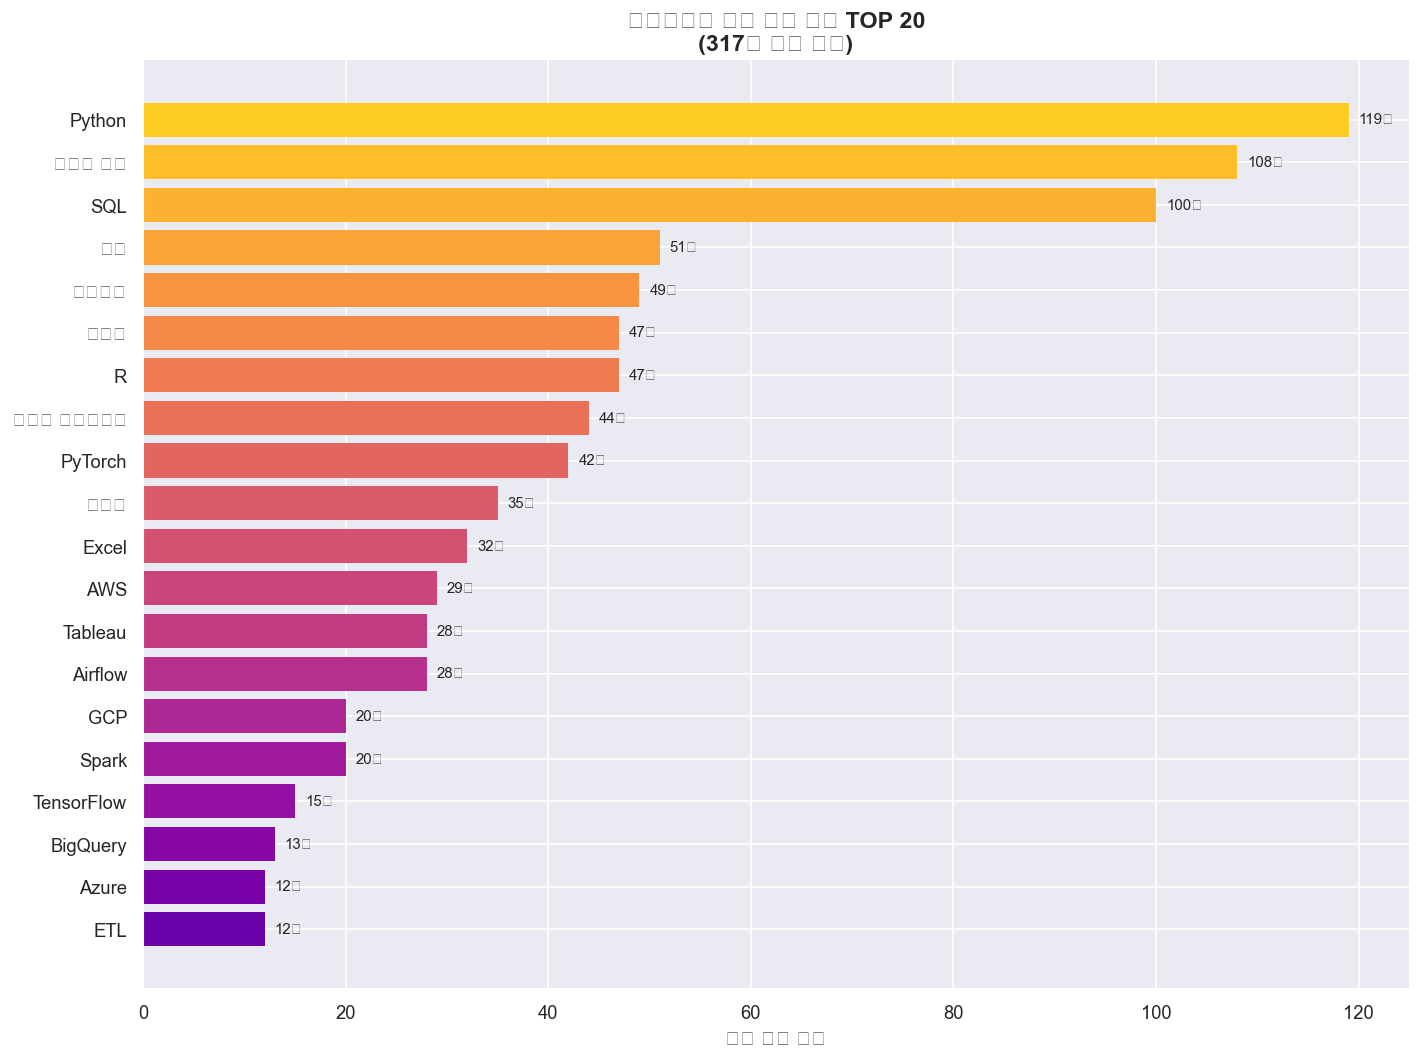


📌 핵심 인사이트:
  Python: 37.5% 공고에서 요구
  SQL: 31.5% 공고에서 요구
  통계: 16.1% 공고에서 요구
  → Python + SQL + 통계는 데이터분석의 3대 핵심 스킬


In [5]:
# 스킬 빈도 데이터
skills_freq = {
    'Python':119, '데이터 분석':108, 'SQL':100, '통계':51, '머신러닝':49,
    '딥러닝':47, 'R':47, '데이터 파이프라인':44, 'PyTorch':42, '시각화':35,
    'Excel':32, 'AWS':29, 'Tableau':28, 'Airflow':28, 'GCP':20,
    'Spark':20, 'TensorFlow':15, 'BigQuery':13, 'Azure':12, 'ETL':12
}
skills_series = pd.Series(skills_freq).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(12, 9))
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(skills_series)))
bars = ax.barh(skills_series.index, skills_series.values, color=colors, edgecolor='none')

for bar, val in zip(bars, skills_series.values):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}건', va='center', fontsize=9)

ax.set_xlabel('공고 언급 횟수')
ax.set_title('데이터분석 직군 요구 스킬 TOP 20\n(317개 공고 기준)', fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('chart_skills.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📌 핵심 인사이트:")
print(f"  Python: {119/317*100:.1f}% 공고에서 요구")
print(f"  SQL: {100/317*100:.1f}% 공고에서 요구")
print(f"  통계: {51/317*100:.1f}% 공고에서 요구")
print(f"  → Python + SQL + 통계는 데이터분석의 3대 핵심 스킬")

## 5. 기업 & 지역 분석

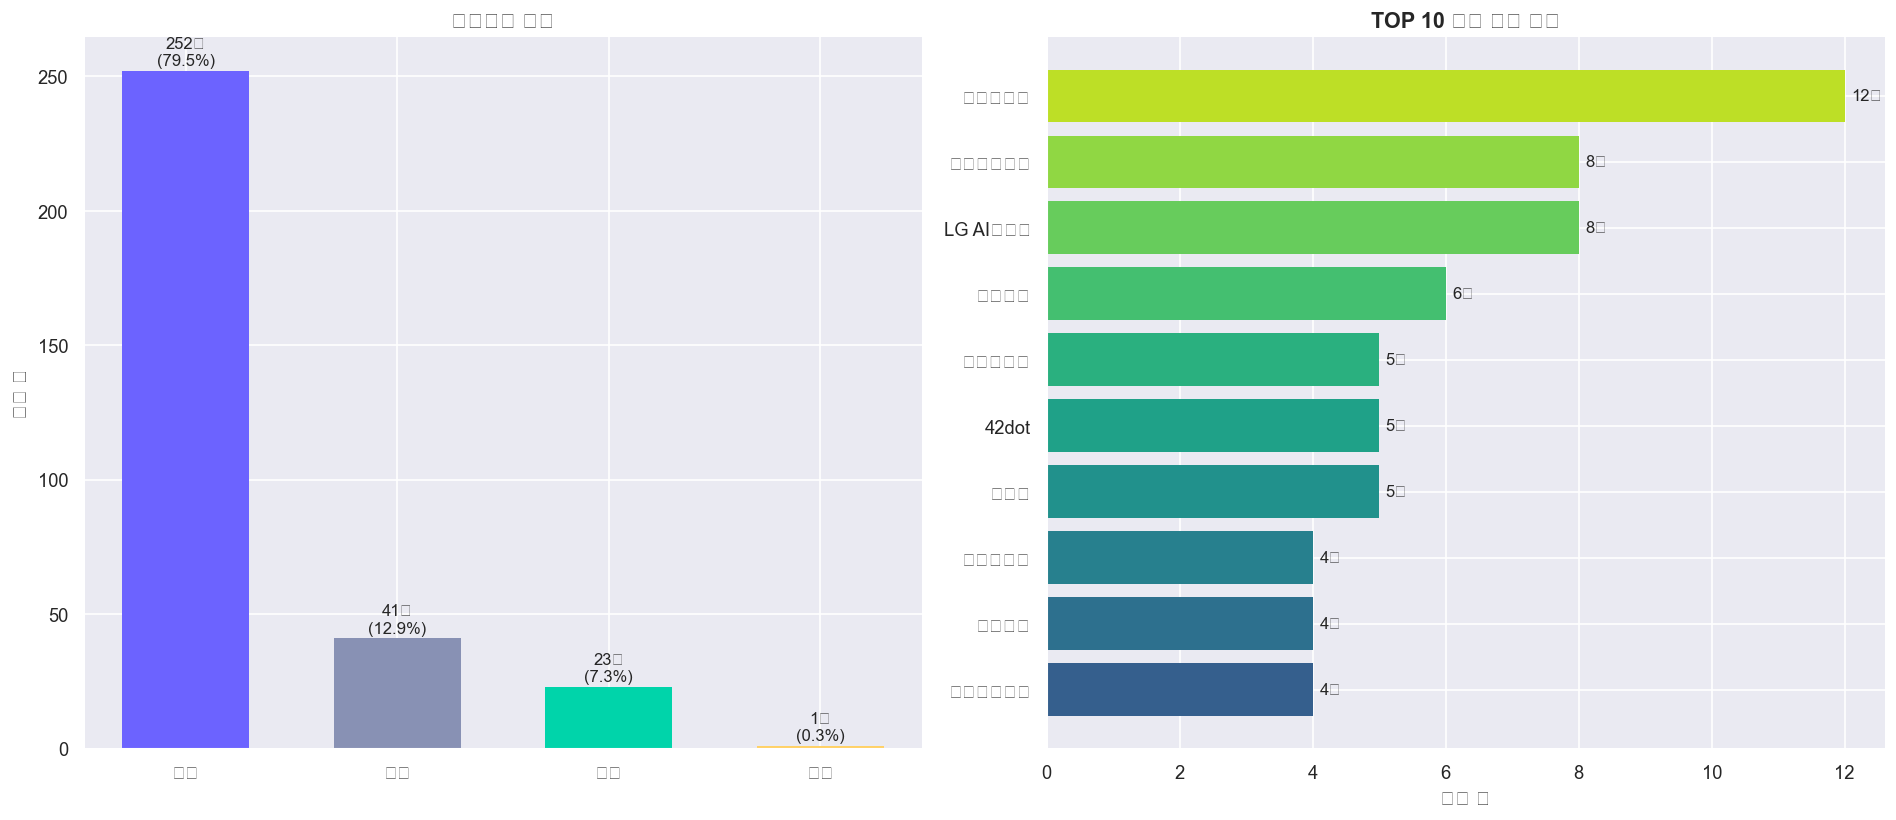

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 지역 분포
city_data = pd.Series({'서울':252, '기타':41, '경기':23, '대전':1})
axes[0].bar(city_data.index, city_data.values,
            color=['#6c63ff','#8891b4','#00d4aa','#ffd166'], edgecolor='none', width=0.6)
for i, (city, cnt) in enumerate(city_data.items()):
    axes[0].text(i, cnt+2, f'{cnt}건\n({cnt/317*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('근무지역 분포', fontsize=13, fontweight='bold')
axes[0].set_ylabel('공고 수')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# TOP 10 기업
co_data = pd.Series({
    '업스테이지':12,'LG AI연구원':8,'우아한형제들':8,'토스뱅크':6,
    '카카오':5,'42dot':5,'넥슨코리아':5,'한국산업은행':4,
    '토스증권':4,'마키나락스':4
}).sort_values()
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(co_data)))
axes[1].barh(co_data.index, co_data.values, color=colors, edgecolor='none')
for i, v in enumerate(co_data.values):
    axes[1].text(v+0.1, i, f'{v}건', va='center', fontsize=10)
axes[1].set_title('TOP 10 채용 활성 기업', fontsize=13, fontweight='bold')
axes[1].set_xlabel('공고 수')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_geo_company.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. 스킬 상관관계 분석

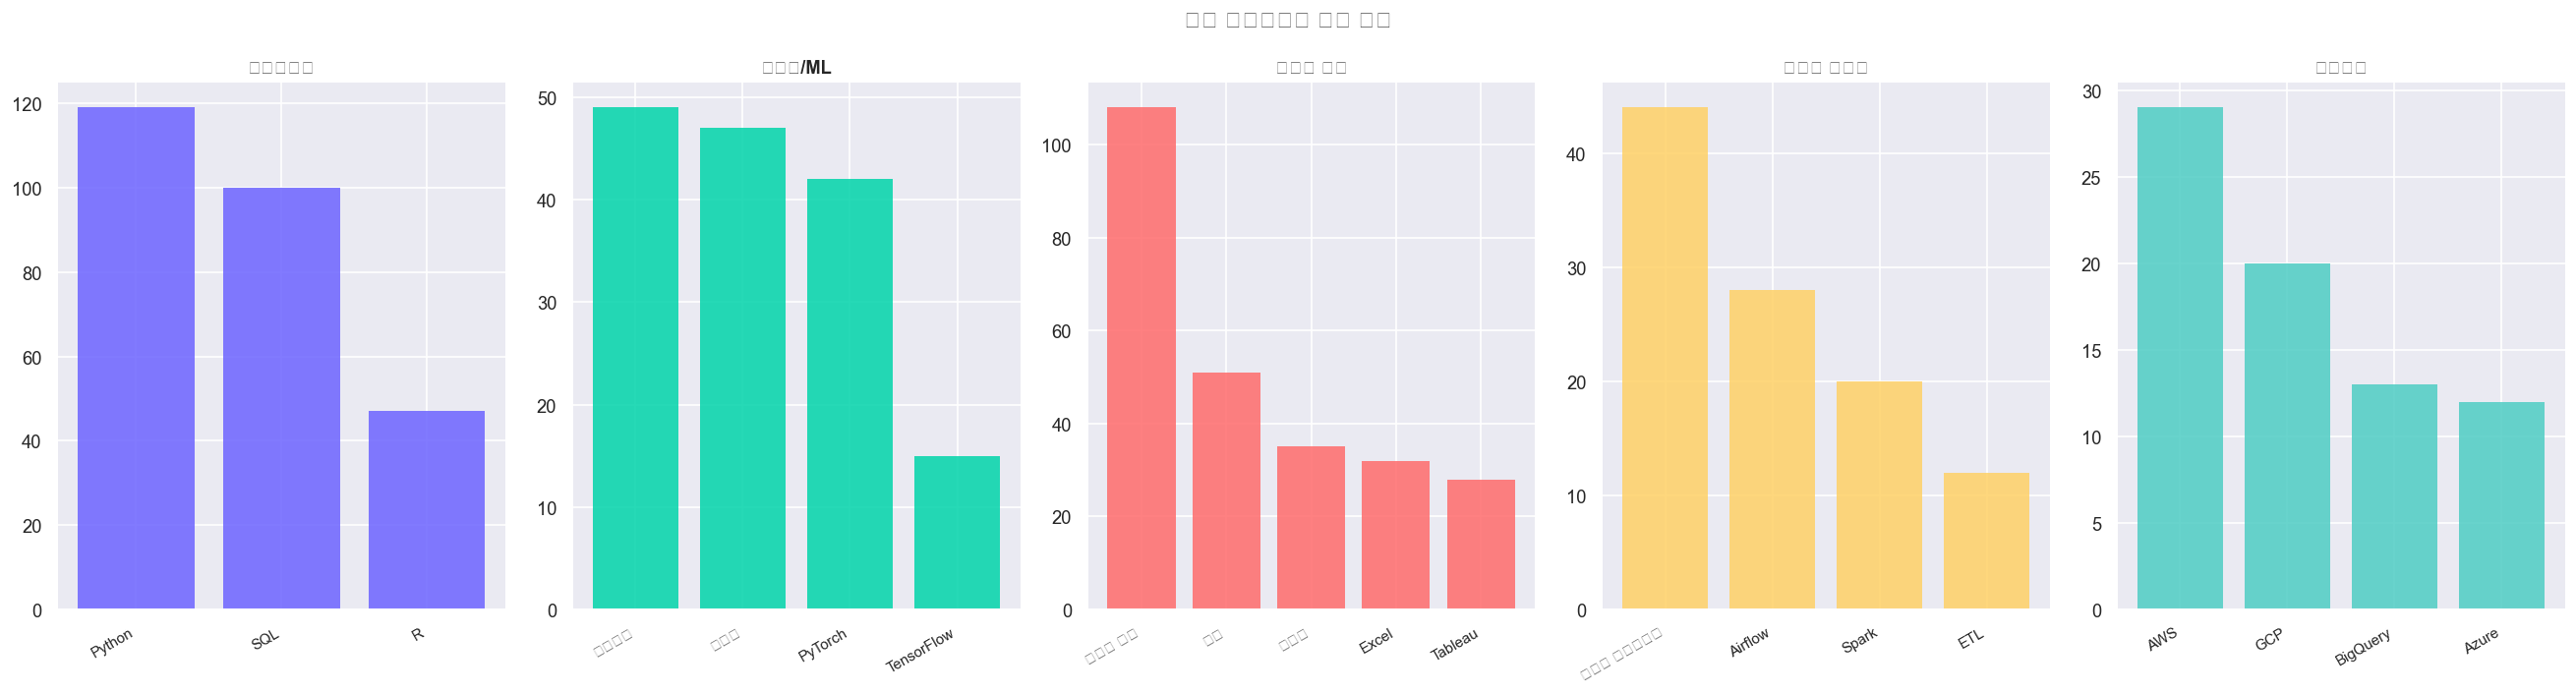

In [7]:
# 스킬 카테고리별 그룹핑
skill_groups = {
    '프로그래밍': {'Python':119, 'SQL':100, 'R':47},
    '딥러닝/ML': {'머신러닝':49, '딥러닝':47, 'PyTorch':42, 'TensorFlow':15},
    '데이터 분석': {'데이터 분석':108, '통계':51, '시각화':35, 'Tableau':28, 'Excel':32},
    '데이터 인프라': {'데이터 파이프라인':44, 'Airflow':28, 'Spark':20, 'ETL':12},
    '클라우드': {'AWS':29, 'GCP':20, 'BigQuery':13, 'Azure':12}
}

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('스킬 카테고리별 수요 분석', fontsize=14, fontweight='bold')

colors_list = ['#6c63ff','#00d4aa','#ff6b6b','#ffd166','#4ecdc4']
for ax, (group, data), color in zip(axes, skill_groups.items(), colors_list):
    s = pd.Series(data).sort_values(ascending=False)
    ax.bar(range(len(s)), s.values, color=color, alpha=0.85, edgecolor='none')
    ax.set_xticks(range(len(s)))
    ax.set_xticklabels(s.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(group, fontweight='bold', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('chart_skill_groups.png', bbox_inches='tight', dpi=150)
plt.show()

## 7. 핵심 인사이트 요약

In [8]:
print('=' * 60)
print('📊 한국 데이터분석 채용시장 핵심 인사이트 (2026년 3월)')
print('=' * 60)

insights = [
    ('시장 규모', '총 317건의 공고, 업스테이지·LG AI·배달의민족 등 주요 기업 집중'),
    ('스킬 트렌드', 'Python(37.5%) > 데이터 분석(34.1%) > SQL(31.5%) 순위. 3개가 핵심 필수'),
    ('직무 구조', 'DS/ML(28.7%) > 기타 > 데이터분석가(14.5%) > DE/ML엔지니어(13.6%)'),
    ('채용 주체', '스타트업이 87.7%로 압도적. 대기업은 9.8%에 불과'),
    ('지역 집중', '서울 79.5%, 경기 7.3%. 수도권 집중 현상 뚜렷'),
    ('고용 형태', '신입+인턴이 30.3%. 진입 기회는 있으나 경력직 수요도 존재'),
    ('클라우드 스킬', 'AWS > GCP > Azure 순. Airflow·Spark 등 파이프라인 도구 수요 증가'),
    ('전략 제언', '취업 준비 우선순위: Python → SQL → 통계 → 시각화 → 클라우드(AWS/GCP)'),
]

for i, (title, content) in enumerate(insights, 1):
    print(f'\n{i}. [{title}]')
    print(f'   {content}')

print('\n' + '=' * 60)

📊 한국 데이터분석 채용시장 핵심 인사이트 (2026년 3월)

1. [시장 규모]
   총 317건의 공고, 업스테이지·LG AI·배달의민족 등 주요 기업 집중

2. [스킬 트렌드]
   Python(37.5%) > 데이터 분석(34.1%) > SQL(31.5%) 순위. 3개가 핵심 필수

3. [직무 구조]
   DS/ML(28.7%) > 기타 > 데이터분석가(14.5%) > DE/ML엔지니어(13.6%)

4. [채용 주체]
   스타트업이 87.7%로 압도적. 대기업은 9.8%에 불과

5. [지역 집중]
   서울 79.5%, 경기 7.3%. 수도권 집중 현상 뚜렷

6. [고용 형태]
   신입+인턴이 30.3%. 진입 기회는 있으나 경력직 수요도 존재

7. [클라우드 스킬]
   AWS > GCP > Azure 순. Airflow·Spark 등 파이프라인 도구 수요 증가

8. [전략 제언]
   취업 준비 우선순위: Python → SQL → 통계 → 시각화 → 클라우드(AWS/GCP)

